In [73]:
import pandas as pd
from helpers import summarize_columns

df = pd.read_parquet("datasets/crash_data.parquet", engine="pyarrow")
summarize_columns(df)

                             name           dtype   unique  size (MB)
0                    COLLISION_ID           int64  2002412         15
1                         BOROUGH             str        5         29
2                        LATITUDE         float64   130276         15
3                       LONGITUDE         float64   101069         15
4                  CRASH DATETIME  datetime64[us]  1184390         15
5       NUMBER OF PERSONS INJURED            Int8       31          3
6        NUMBER OF PERSONS KILLED            Int8        8          3
7   NUMBER OF PEDESTRIANS INJURED            Int8       14          3
8    NUMBER OF PEDESTRIANS KILLED            Int8        6          3
9       NUMBER OF CYCLIST INJURED            Int8        5          3
10       NUMBER OF CYCLIST KILLED            Int8        3          3
11     NUMBER OF MOTORIST INJURED            Int8       29          3
12      NUMBER OF MOTORIST KILLED            Int8        6          3
13  CONTRIBUTING FAC

In [74]:
# --- Filtering in lethal cases --- #
df = df[df["NUMBER OF PERSONS KILLED"].notna() & df["NUMBER OF PERSONS KILLED"] != 0]

# --- Loading the person dataset and joining it with crash dataset --- #
pers_df = pd.read_parquet("datasets/person_data.parquet", engine="pyarrow")

merg_df = df.join(
    pers_df, on="COLLISION_ID", how="inner", lsuffix="_crash", rsuffix="_person"
)

del df, pers_df
#  summarize_columns(merg_df)

## Data Filtering and cleaning

In [75]:
# --- Filtering in only cis gender people and when lethal cases of persons being iside the vechilde (i.e. Occupant) --- #
merg_df = merg_df[
    merg_df["PERSON_SEX"].isin(["M", "F"]) & merg_df["PERSON_TYPE"].isin(["Occupant"])
]

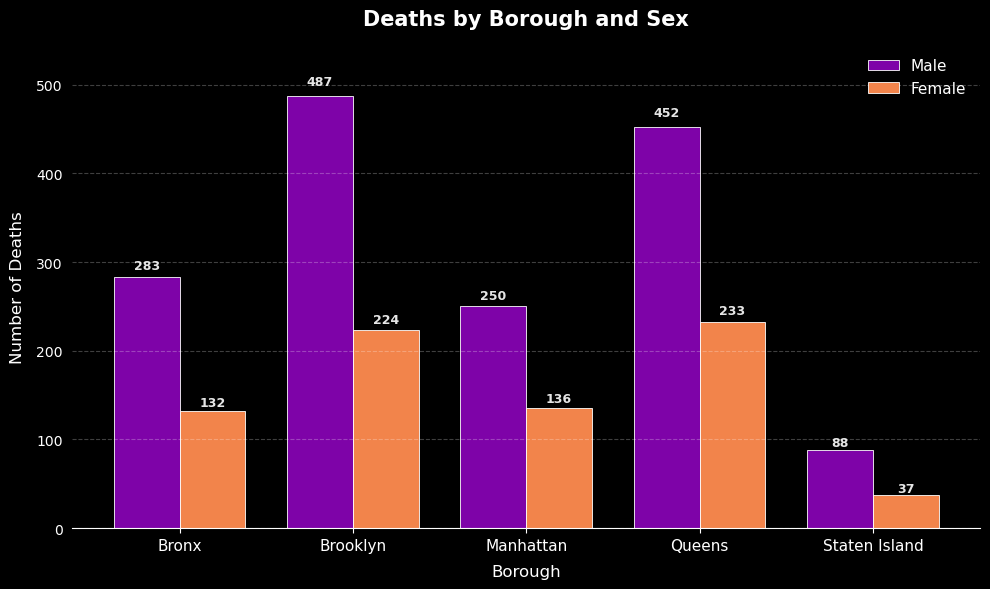

In [76]:
import matplotlib.pyplot as plt

counts = (
    merg_df.groupby(["BOROUGH", "PERSON_SEX"]).size().unstack(fill_value=0)[["M", "F"]]
)

male_color = plt.cm.plasma(0.25)
female_color = plt.cm.plasma(0.70)

with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize=(10, 6))
    x = range(len(counts))
    w = 0.38

    bars_m = ax.bar(
        [i - w / 2 for i in x],
        counts["M"],
        w,
        label="Male",
        color=male_color,
        edgecolor="white",
        linewidth=0.6,
    )
    bars_f = ax.bar(
        [i + w / 2 for i in x],
        counts["F"],
        w,
        label="Female",
        color=female_color,
        edgecolor="white",
        linewidth=0.6,
    )

    for bars in (bars_m, bars_f):
        for bar in bars:
            h = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                h * 1.02,
                f"{int(h):,}",
                ha="center",
                va="bottom",
                fontsize=9,
                color="white",
                alpha=0.9,
                fontweight="bold",
            )

    ax.set_xticks(list(x))
    ax.set_xticklabels(counts.index, fontsize=11)
    ax.set_xlabel("Borough", fontsize=12, labelpad=8)
    ax.set_ylabel("Number of Deaths", fontsize=12, labelpad=8)
    ax.set_title("Deaths by Borough and Sex", fontsize=15, fontweight="bold", pad=14)
    ax.set_ylim(0, counts.values.max() * 1.12)
    ax.grid(axis="y", linestyle="--", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.tick_params(left=False)
    ax.legend(frameon=False, fontsize=11, loc="upper right")

    plt.tight_layout()
    plt.show()